# Data Science Cohort 7
**Name:** Victor Ogwamenhlu

## TASK 3 - PIZZA PLACE SALES ANALYSIS

### IMPORT LIBRARIES

In [1]:
#import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import plotly.express as px

plt.style.use("ggplot")

In [2]:
#Loading Dataset
orders = pd.read_csv(r"C:\Users\USER\Desktop\PYthon\Data Sets\pizza_sales\orders.csv")
order_details = pd.read_csv(r"C:\Users\USER\Desktop\PYthon\Data Sets\pizza_sales\order_details.csv")
pizzas = pd.read_csv(r"C:\Users\USER\Desktop\PYthon\Data Sets\pizza_sales\pizzas.csv")
pizza_types = pd.read_csv(r"C:\Users\USER\Desktop\PYthon\Data Sets\pizza_sales\pizza_types.csv", encoding='latin1')
data_dictionary = pd.read_csv(r"C:\Users\USER\Desktop\PYthon\Data Sets\pizza_sales\data_dictionary.csv")

### Understanding my Data

In [3]:

pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [4]:
pizza_types

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."
5,thai_ckn,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
6,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
7,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
8,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
9,ital_cpcllo,The Italian Capocollo Pizza,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,..."


In [5]:
orders.head()


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [6]:
order_details.head()


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [7]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [8]:
data_dictionary

,Table,Field,Description
0,orders,order_id,Unique identifier for each order placed by a t...
1,orders,date,Date the order was placed (entered into the sy...
2,orders,time,Time the order was placed (entered into the sy...
3,order_details,order_details_id,Unique identifier for each pizza placed within...
4,order_details,order_id,Foreign key that ties the details in each orde...
5,order_details,pizza_id,Foreign key that ties the pizza ordered to its...
6,order_details,quantity,Quantity ordered for each pizza of the same ty...
7,pizzas,pizza_id,Unique identifier for each pizza (constituted ...
8,pizzas,pizza_type_id,Foreign key that ties each pizza to its broade...
9,pizzas,size,"Size of the pizza (Small, Medium, Large, X Lar..."


### Observation
The dataset consist of four related tables or columns:

- **Orders**: Contains the date and time of each order.
- **Order Details**: Contains the pizzas ordered and their quantities.
- **Pizzas**: Contains pizza sizes and prices.
- **Pizza Types**: Contains pizza names, categories, and ingredients information.
- **Data_Dictionary**: explains what each column means, its data type, and its description.

In [9]:
### Merging my datasets for proper understanding 

Sales = (orders. merge(order_details, on = "order_id", how="inner")
         .merge(pizzas, on = "pizza_id", how="inner")
         .merge(pizza_types, on = "pizza_type_id", how="inner"))

In [10]:
Sales.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


## Data Inspection

In [11]:
Sales.shape

(48620, 12)

In [12]:
Sales.tail()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
48619,21350,2015-12-31,23:02:05,48620,bbq_ckn_s,1,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."


In [13]:
Sales.describe()

,order_id,order_details_id,quantity,price
count,48620.000000,48620.000000,48620.000000,48620.000000
mean,10701.479761,24310.500000,1.019622,16.494132
std,6180.119770,14035.529381,0.143077,3.621789
min,1.000000,1.000000,1.000000,9.750000
25%,5337.000000,12155.750000,1.000000,12.750000
50%,10682.500000,24310.500000,1.000000,16.500000
75%,16100.000000,36465.250000,1.000000,20.250000
max,21350.000000,48620.000000,4.000000,35.950000


In [14]:
Sales.columns

Index(['order_id', 'date', 'time', 'order_details_id', 'pizza_id', 'quantity',
       'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients'],
      dtype='object')

In [15]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [16]:
Sales["date"].value_counts()

date
2015-11-26    261
2015-11-27    259
2015-10-15    258
2015-07-04    233
2015-07-03    207
             ... 
2015-12-27     87
2015-11-22     82
2015-12-29     77
2015-03-22     76
2015-12-30     73
Name: count, Length: 358, dtype: int64

In [17]:
# Checking for Missing Values

Sales.isna().sum()

order_id            0
date                0
time                0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [18]:
# Checking for duplicate Records
Sales.duplicated().sum()

np.int64(0)

In [19]:
# Checking the Data Types

Sales.dtypes

order_id              int64
date                 object
time                 object
order_details_id      int64
pizza_id             object
quantity              int64
pizza_type_id        object
size                 object
price               float64
name                 object
category             object
ingredients          object
dtype: object

## Converting Date and Time to DateTime Data Type


In [20]:
#coverting Date

Sales["date"]= pd.to_datetime(Sales["date"])

In [21]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  object        
 3   order_details_id  48620 non-null  int64         
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  int64         
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 4.5+ MB


In [22]:
#Converting Time

Sales["time"]= pd.to_datetime(Sales["time"], format= "%H:%M:%S") 

In [23]:
Sales.dtypes

order_id                     int64
date                datetime64[ns]
time                datetime64[ns]
order_details_id             int64
pizza_id                    object
quantity                     int64
pizza_type_id               object
size                        object
price                      float64
name                        object
category                    object
ingredients                 object
dtype: object

## Creating New Columns to aid our analysis

In [24]:
# Creating Revenue using Sales Quantity and Sales Price

Sales["Revenue"]= Sales["quantity"] * Sales["price"]

Sales["Revenue"]

0        13.25
1        16.00
2        18.50
3        20.75
4        16.00
         ...  
48615    16.75
48616    17.95
48617    12.00
48618    20.25
48619    12.75
Name: Revenue, Length: 48620, dtype: float64

In [25]:
# creating Hour using time
Sales["Hour"] = Sales["time"].dt.hour

In [26]:
#Creating Month column using date

Sales["Month"] = Sales["date"].dt.month_name()

In [27]:
Sales["Weekday"] = Sales["date"].dt.day_name()

In [28]:
Sales.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,Revenue,Hour,Month,Weekday
0,1,2015-01-01,1900-01-01 11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,January,Thursday
1,2,2015-01-01,1900-01-01 11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,January,Thursday
2,2,2015-01-01,1900-01-01 11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,January,Thursday
3,2,2015-01-01,1900-01-01 11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,January,Thursday
4,2,2015-01-01,1900-01-01 11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,January,Thursday


In [29]:
Sales

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,Revenue,Hour,Month,Weekday
0,1,2015-01-01,1900-01-01 11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,January,Thursday
1,2,2015-01-01,1900-01-01 11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,January,Thursday
2,2,2015-01-01,1900-01-01 11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,January,Thursday
3,2,2015-01-01,1900-01-01 11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,January,Thursday
4,2,2015-01-01,1900-01-01 11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,January,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,21348,2015-12-31,1900-01-01 21:23:10,48616,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",16.75,21,December,Thursday
48616,21348,2015-12-31,1900-01-01 21:23:10,48617,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",17.95,21,December,Thursday
48617,21348,2015-12-31,1900-01-01 21:23:10,48618,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",12.00,21,December,Thursday
48618,21349,2015-12-31,1900-01-01 22:09:54,48619,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",20.25,22,December,Thursday


In [30]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  datetime64[ns]
 3   order_details_id  48620 non-null  int64         
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  int64         
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
 12  Revenue           48620 non-null  float64       
 13  Hour              48620 non-null  int32         
 14  Month             4862

## Data Cleaning Observation and Summary
- The dataset contains no significant missing or duplicate values.
- Date and Time columns were converted in the appropriate DateTime Format Data Type.
- Addition columns were created or added such as: Revenue, Month, Hour and Weekday to help support our analysis

## ANALYSIS OF DATA

In [31]:
# Total Revenue Generated

Total_Revenue = Sales["Revenue"].sum()

print (f"Total Revenue: ${Total_Revenue:,}")

Total Revenue: $817,860.0499999999


#### Insight:
The Pizza Place generated about $817,860 in revenue during the year, which indicate a healthy sales performance

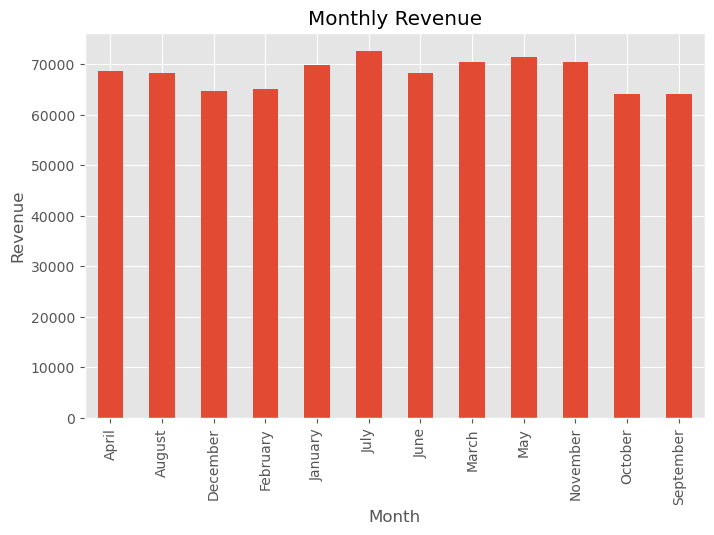

In [32]:
monthly_revenue = Sales.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="bar",
                     figsize = (8,5))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

#### Observation:
The Pizza Place made the most revenue in the month of July which is key indication of influx of customers

#### **Recommedation**:
- Adequate staffing is required to meet the high demands of customers.
- Possible marketing strategies for the business to maximize revenue

### TOTAL QUANTITY SOLD

In [33]:
Total_quantity_sold = Sales["quantity"].sum()

print (f"Total Quantity Sold: {Total_quantity_sold:,}")

Total Quantity Sold: 49,574


### TOTAL ORDERS RECIEVED

In [34]:
Total_orders = Sales["order_id"].nunique()

print (f"Total Orders recieved from customers: {Total_orders:,}")

Total Orders recieved from customers: 21,350


### HOW MANY PIZZA TYPES DO THEY SELL

In [35]:
pizza_type_count = Sales["name"].nunique()

print(f"Number of Pizza Types Sold: {pizza_type_count}")

Number of Pizza Types Sold: 32


### THE AVERAGE PRICE OF THE PIZZAS

In [36]:
Average_pizza_price = Sales["price"].mean()

print(f"The Average Pizza Price: {Average_pizza_price}")

The Average Pizza Price: 16.494132044426163


Text(0, 0.5, 'Frequency')

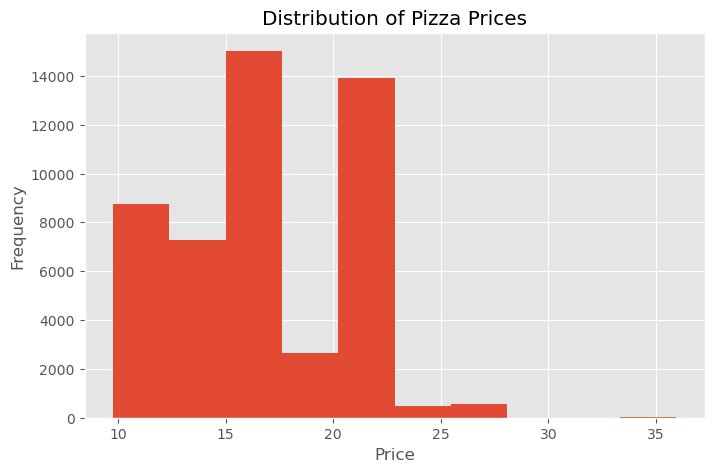

In [37]:
#Visualisation of Pizza Prices
plt.figure(figsize=(8,5))
plt.hist(Sales["price"], bins=10)

plt.title("Distribution of Pizza Prices")
plt.xlabel("Price")

plt.ylabel("Frequency")

### PEAK SALES HOURS 

In [38]:
Hourly = Sales.groupby("Hour")["Revenue"].sum()

Hourly

Hour
9         83.00
10       303.65
11     44935.80
12    111877.90
13    106065.70
14     59201.40
15     52992.30
16     70055.40
17     86237.45
18     89296.85
19     72628.90
20     58215.40
21     42029.80
22     22815.15
23      1121.35
Name: Revenue, dtype: float64

Text(0, 0.5, 'Revenue')

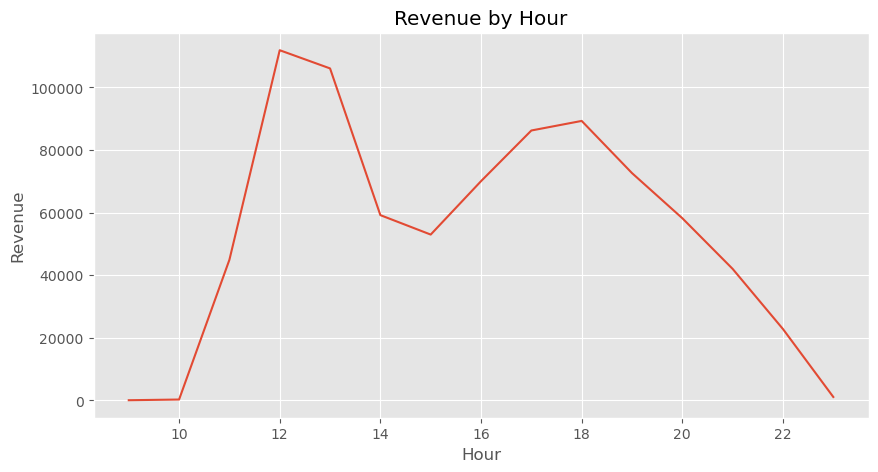

In [39]:
Hourly.plot(figsize=(10,5))

plt.title("Revenue by Hour")

plt.xlabel("Hour")
plt.ylabel("Revenue")

### SALES MADE ON EACH DAY OF THE WEEK

In [40]:
sales_by_weekday = Sales.groupby("Weekday")["Revenue"].sum()

sales_by_weekday = sales_by_weekday.reindex(["Monday",
                                   "Tuesday",
                                   "Wednesday",
                                   "Thursday",
                                   "Friday",
                                   "Saturday",
                                   "Sunday"])

In [41]:
sales_by_weekday

Weekday
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: Revenue, dtype: float64

Text(0.5, 1.0, 'Revenue by Day of The Week')

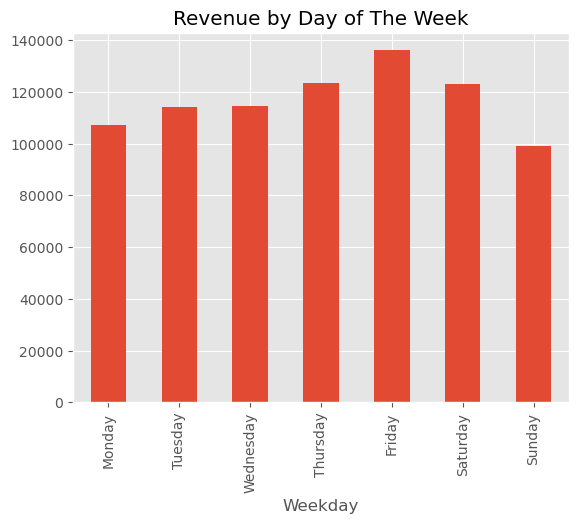

In [42]:
#Visualisation

sales_by_weekday.plot(kind="bar")
plt.title("Revenue by Day of The Week")

#### Observation:
- Friday records the highest sales due to increased in customer traffic going into the weekend

#### **Recommedation**:
- Develop trageted weekday marketing campaigns to increase sales on slower days.

### TOP FIVE BEST SELLING PIZZAS

In [43]:
Top5 = (Sales.groupby("name")["quantity"].sum().sort_values(ascending=False).head())

<Axes: ylabel='name'>

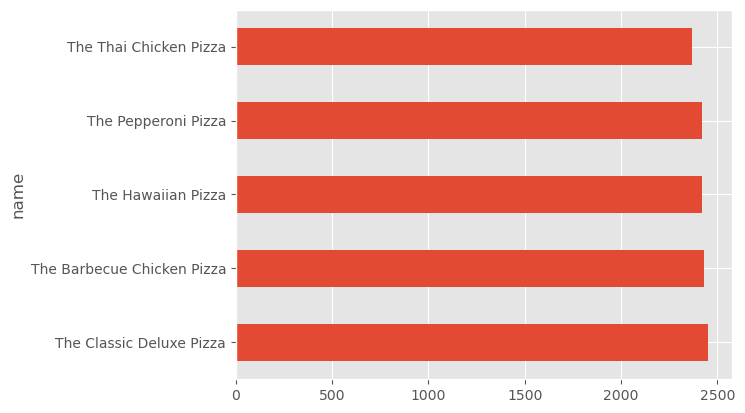

In [44]:
Top5.plot(kind="barh")

In [45]:
top_5 = Sales.groupby("name")["quantity"].sum().reset_index()

In [46]:
#To sort out our data to get the top 5

top_5.sort_values(by= "quantity", ascending = False, inplace=True)

In [47]:
#to get our top 5 best selling Pizza 
top_5.head(5)

,name,quantity
7,The Classic Deluxe Pizza,2453
0,The Barbecue Chicken Pizza,2432
12,The Hawaiian Pizza,2422
20,The Pepperoni Pizza,2418
30,The Thai Chicken Pizza,2371


#### **Recommedation**:
- The above data shows the pizzas that contributed significantly to the overall sales and should remain highly stocked to avoid shortages


### SALES MADE IN EACH MONTH (MONTHLY REVENUE)

In [48]:
monthly_revenue = Sales.groupby("Month")["Revenue"].sum()

monthly_revenue = monthly_revenue.reindex(["January",
                                  "February",
                                  "March",
                                  "April",
                                  "May",
                                  "June",
                                  "July",
                                  "August",
                                  "September",
                                  "October",
                                  "November",
                                  "December"])

Text(0, 0.5, 'Revenue')

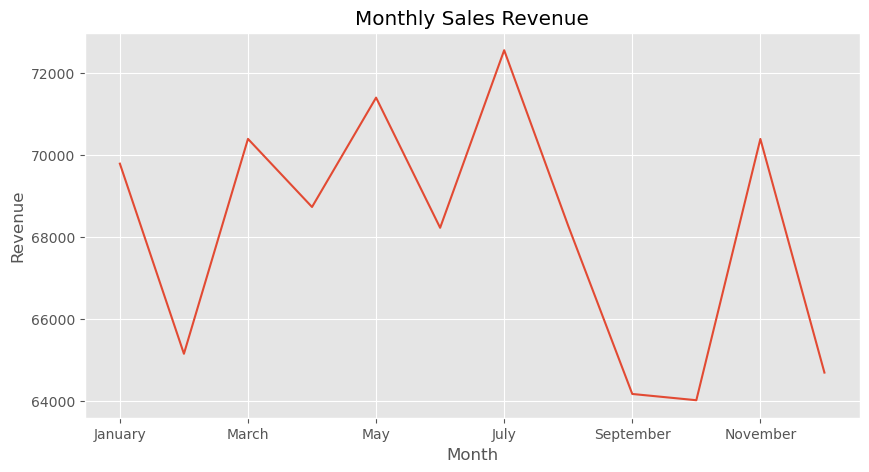

In [49]:
#Visualizing Monthly Sales Revenue
monthly_revenue.plot(figsize=(10,5))

plt.title("Monthly Sales Revenue")

plt.xlabel("Month")
plt.ylabel("Revenue")

#### Observation
Sales fluctuate throughout the year with significant increase during the month of July - August and noticeable decline in the month of October

#### **Recommendation**
- Increase staffing during these months to improve customer service and reduce waiting time
- Leverage on seasonal promotions during this high performing months to maximize revenue

### LOW SELLING PIZZAS

In [50]:
#Getting the bottom 5 pizzas types not making good sales
low_selling_pizzas = Sales.groupby("name")["quantity"].sum().reset_index()

In [51]:
#To sort out our data to get the lowest selling 5

low_selling_pizzas.sort_values(by= "quantity", inplace=True)

In [52]:
low_selling_pizzas.head(5)



,name,quantity
2,The Brie Carre Pizza,490
16,The Mediterranean Pizza,934
3,The Calabrese Pizza,937
28,The Spinach Supreme Pizza,950
24,The Soppressata Pizza,961


#### Observation:
The above 5 pizzas contributed minimally to the overall sales and revenue.

#### **Recommedation**:
A thorough invesigation should be carried out on these pizza types to determine; if better marketing is needed, recipe imporovement, price adjustment is needed or total removal from the menu list in order to simplify operations and reduce cost of inventory


### REVENUE BY PIZZA SIZE

In [53]:
size = Sales.groupby("size")["Revenue"].sum()

<Axes: xlabel='size'>

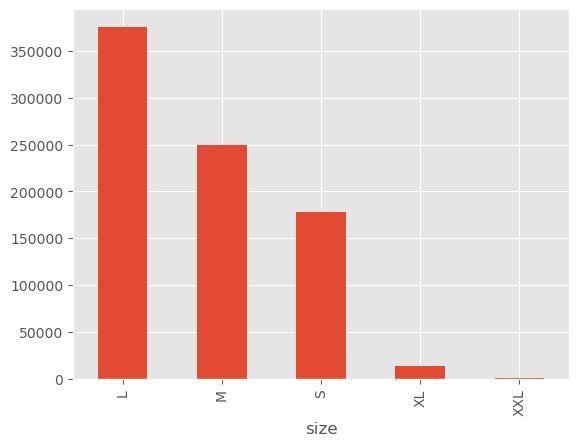

In [54]:
size.plot(kind="bar")

#### Observation:
More revenue were generated from the large pizza size

#### **Recommendation**
- Channel more attention in producing Large pizza sizes
- XXL pizza size may require marketing efforte or removal from the inventory list to minimize inventory cost

### ORDERS PER HOUR


In [55]:
orders_per_hour = Sales.groupby("Hour")["order_id"].count()

In [56]:
orders_per_hour

Hour
9        4
10      17
11    2672
12    6543
13    6203
14    3521
15    3170
16    4185
17    5143
18    5359
19    4350
20    3487
21    2528
22    1370
23      68
Name: order_id, dtype: int64

<Axes: xlabel='Hour'>

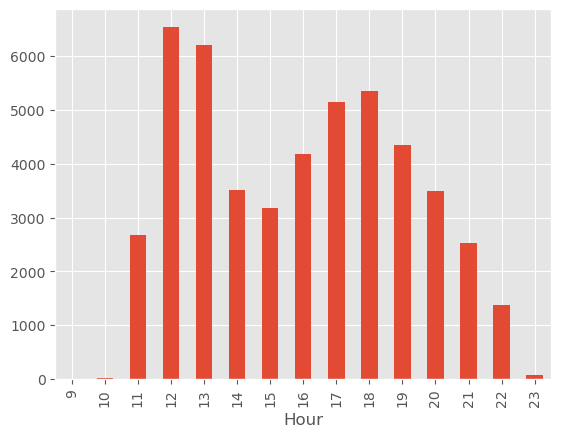

In [57]:
orders_per_hour.plot(kind="bar")

#### Observation:
Customers demand peaks during lunch (12pm - 2pm) and dinner from the hour of 5p, - 8pm

#### **Recommendation**
- Need for adequate staffing during these periods


### SALES HEATMAP

In [58]:
#Creating a pivot table

days = ["Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"]

heatmap_data = Sales.pivot_table(values="Revenue", index="Weekday", columns="Hour", aggfunc="sum", fill_value=0)

heatmap_data = heatmap_data.reindex(days)

In [59]:
#visualisation
fig = px.imshow(heatmap_data, labels=dict(x="Hour", y="Weekday", colour="Revenue"),
                title="Revenue Heatmap by Weekly and Hour", aspect="auto")

fig.show()

### TOP INGREDIENTS

In [60]:
Sales["ingredients"].value_counts().head(10)

ingredients
Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon                                                 2416
Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce                  2372
Sliced Ham, Pineapple, Mozzarella Cheese                                                             2370
Mozzarella Cheese, Pepperoni                                                                         2369
Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce                                   2315
Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese                  2302
Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic                     1887
Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic                              1887
Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce         1885
Ricotta Cheese, Gorgonzola Piccant